# Dataset optimization comparison (body mass, target island 3)

This notebook compares three experiments:
- `PEVmean-GA` (individual-level subset optimization)
- `Island-GA` (island subset optimization)
- `Data Shapley` island-wise sweep (`shapley_mean`)

All analyses are restricted to `trait = body_mass` and `target_island = 3` when available.

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Paths ----
PEV_PATH = Path('../outputs/pevmean_ga/pevmean_ga_results.csv')
ISLAND_GA_PATH = Path('../outputs/island_ga/island_ga_results.csv')
SHAPLEY_ROWS_PATH = Path('../outputs/tmc_shapley_sweep_all_traits/body_mass/target_3/remove_curve_sweep_rows.csv')

for p in [PEV_PATH, ISLAND_GA_PATH, SHAPLEY_ROWS_PATH]:
    if not p.exists():
        raise FileNotFoundError(p)

pev = pd.read_csv(PEV_PATH)
iga = pd.read_csv(ISLAND_GA_PATH)
shap = pd.read_csv(SHAPLEY_ROWS_PATH)

print('PEVmean-GA:', pev.shape)
print('Island-GA:', iga.shape)
print('Shapley rows:', shap.shape)

PEVmean-GA: (130, 11)
Island-GA: (60, 18)
Shapley rows: (22500, 17)


In [24]:
# ---- User-tunable comparison settings ----
SHAPLEY_N_CAL = 40
SHAPLEY_N_PERM = 150

# Restrict to target/trait when columns exist
def restrict(df):
    out = df.copy()
    if 'trait' in out.columns:
        out = out[out['trait'] == 'body_mass']
    if 'target_island' in out.columns:
        out = out[out['target_island'] == 3]
    return out

pev = restrict(pev)
iga = restrict(iga)
shap = restrict(shap)

# Use one Shapley sweep cell for direct comparison (same n_cal each run)
shap_cmp = shap[(shap['n_cal_samples'] == SHAPLEY_N_CAL) & (shap['n_permutations'] == SHAPLEY_N_PERM)].copy()

print('Filtered PEVmean-GA:', pev.shape)
print('Filtered Island-GA:', iga.shape)
print('Filtered Shapley rows:', shap_cmp.shape)
shap_cmp

Filtered PEVmean-GA: (130, 11)
Filtered Island-GA: (60, 18)
Filtered Shapley rows: (900, 17)


,n_removed,n_islands_remaining,n_individuals_remaining,corr_eval,mse_adj,method,order_seed,n_islands,n_individuals,target_island,target_island_name,repeat,split_seed,n_permutations,trait,cal_fraction,n_cal_samples
1260,14,1,292,0.103097,1.014732,shapley_mean,-1,1,292,3,Selvær,0,800793894,150,body_mass,0.206186,40
1261,13,2,384,0.027120,1.033556,shapley_mean,-1,2,384,3,Selvær,0,800793894,150,body_mass,0.206186,40
1262,12,3,586,0.030049,1.039482,shapley_mean,-1,3,586,3,Selvær,0,800793894,150,body_mass,0.206186,40
1263,11,4,744,0.038558,1.044449,shapley_mean,-1,4,744,3,Selvær,0,800793894,150,body_mass,0.206186,40
1264,10,5,917,0.037109,1.047176,shapley_mean,-1,5,917,3,Selvær,0,800793894,150,body_mass,0.206186,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21595,4,11,4254,0.063374,0.690517,random_individual,4,11,4254,3,Selvær,9,926404650,150,body_mass,0.206186,40
21596,3,12,4651,0.089770,0.686699,random_individual,4,12,4651,3,Selvær,9,926404650,150,body_mass,0.206186,40
21597,2,13,4853,0.097961,0.684513,random_individual,4,13,4853,3,Selvær,9,926404650,150,body_mass,0.206186,40
21598,1,14,5411,0.129803,0.670529,random_individual,4,14,5411,3,Selvær,9,926404650,150,body_mass,0.206186,40


In [25]:
# ---- Build a unified table of optimized methods ----
pev_opt = pev[pev['method'] == 'pevmean_ga'].copy()
pev_opt['experiment'] = 'PEVmean-GA'
pev_opt['corr_test'] = pev_opt['corr_eval']
pev_opt['mse_test'] = pev_opt['mse_adj']

iga_opt = iga[iga['method'] == 'island_ga'].copy()
iga_opt['experiment'] = 'Island-GA'
iga_opt['corr_test'] = iga_opt['corr_eval_test']
iga_opt['mse_test'] = iga_opt['mse_adj_test']

shap_opt = shap_cmp[shap_cmp['method'] == 'shapley_mean'].copy()
shap_opt['experiment'] = 'Data Shapley (island-wise)'
shap_opt['corr_test'] = shap_opt['corr_eval']
shap_opt['mse_test'] = shap_opt['mse_adj']

common_cols = ['experiment', 'n_individuals', 'corr_test', 'mse_test']
all_opt = pd.concat([
    pev_opt[common_cols],
    iga_opt[common_cols],
    shap_opt[common_cols],
], ignore_index=True)

overview = (
    all_opt.groupby('experiment', as_index=False)
    .agg(
        n_rows=('corr_test', 'size'),
        corr_mean=('corr_test', 'mean'),
        corr_std=('corr_test', 'std'),
        corr_max=('corr_test', 'max'),
        mse_mean=('mse_test', 'mean'),
        n_ind_min=('n_individuals', 'min'),
        n_ind_max=('n_individuals', 'max'),
    )
    .sort_values('corr_mean', ascending=False)
)
overview

,experiment,n_rows,corr_mean,corr_std,corr_max,mse_mean,n_ind_min,n_ind_max
1,Island-GA,5,0.246782,0.018560,0.274840,0.867273,2214,3219
2,PEVmean-GA,25,0.206534,0.033968,0.272557,0.900023,500,5503
0,Data Shapley (island-wise),150,0.141526,0.158646,0.446600,0.940986,92,5503


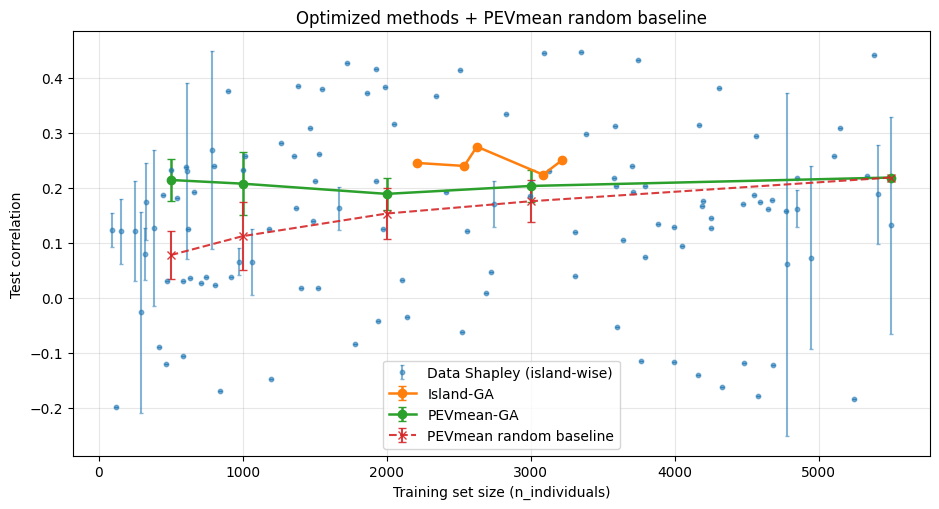

,experiment,n_individuals,corr_mean,corr_std,n
0,Data Shapley (island-wise),92,0.123565,0.031232,2
1,Data Shapley (island-wise),119,-0.198700,NaN,1
2,Data Shapley (island-wise),158,0.120882,0.058673,5
3,Data Shapley (island-wise),250,0.121834,0.090682,2
4,Data Shapley (island-wise),292,-0.026388,0.183118,2
...,...,...,...,...,...
124,PEVmean-GA,500,0.214219,0.037433,5
125,PEVmean-GA,1000,0.207504,0.056859,5
126,PEVmean-GA,2000,0.188944,0.028837,5
127,PEVmean-GA,3000,0.203346,0.028265,5


In [26]:
# ---- Plot 1: corr_test vs training set size ----
plot_df = (
    all_opt.groupby(['experiment', 'n_individuals'], as_index=False)
    .agg(corr_mean=('corr_test', 'mean'), corr_std=('corr_test', 'std'), n=('corr_test', 'size'))
    .sort_values(['experiment', 'n_individuals'])
)

# Add PEVmean random baseline to the same figure
pev_random_plot = (
    pev[pev['method'] == 'random_individual']
    .groupby('n_individuals', as_index=False)
    .agg(corr_mean=('corr_eval', 'mean'), corr_std=('corr_eval', 'std'), n=('corr_eval', 'size'))
    .sort_values('n_individuals')
)

plt.figure(figsize=(9.5, 5.2))

for exp, sub in plot_df.groupby('experiment'):
    sub = sub.sort_values('n_individuals')

    if exp == 'Data Shapley (island-wise)':
        # Many points: show dots only (no connecting line)
        plt.errorbar(
            sub['n_individuals'],
            sub['corr_mean'],
            yerr=sub['corr_std'].fillna(0.0),
            fmt='o',
            linestyle='none',
            markersize=3.2,
            alpha=0.55,
            capsize=1.5,
            label=exp
        )
    else:
        plt.errorbar(
            sub['n_individuals'],
            sub['corr_mean'],
            yerr=sub['corr_std'].fillna(0.0),
            marker='o',
            capsize=3,
            linewidth=1.8,
            label=exp
        )

plt.errorbar(
    pev_random_plot['n_individuals'],
    pev_random_plot['corr_mean'],
    yerr=pev_random_plot['corr_std'].fillna(0.0),
    marker='x',
    linestyle='--',
    linewidth=1.5,
    capsize=3,
    alpha=0.9,
    label='PEVmean random baseline'
)

plt.xlabel('Training set size (n_individuals)')
plt.ylabel('Test correlation')
plt.title('Optimized methods + PEVmean random baseline')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plot_df

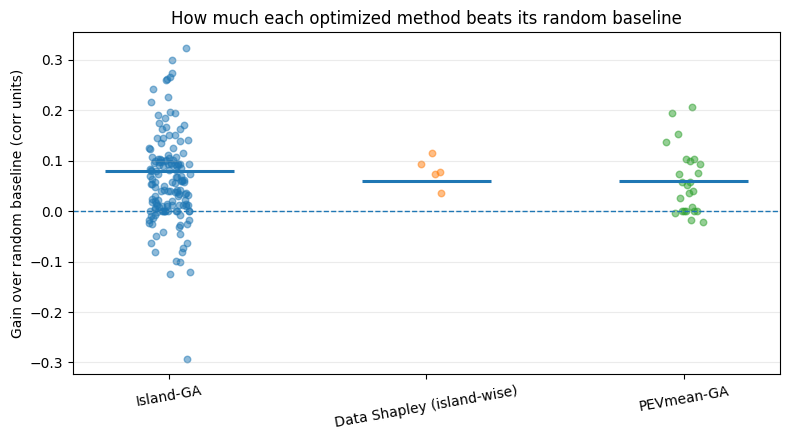

,experiment,n,gain_mean,gain_std,gain_min,gain_max,frac_positive
1,Island-GA,5,0.079444,0.029161,0.035784,0.114980,1.000000
0,Data Shapley (island-wise),150,0.060104,0.087573,-0.292527,0.323806,0.773333
2,PEVmean-GA,25,0.059123,0.064874,-0.021157,0.206736,0.680000


In [27]:
# ---- Gain over each experiment's random baseline ----
# 1) PEVmean-GA vs random_individual (mean over random orders per repeat/size)
pev_rand = (
    pev[pev['method'] == 'random_individual']
    .groupby(['repeat', 'repeat_seed', 'n_individuals'], as_index=False)['corr_eval']
    .mean()
    .rename(columns={'corr_eval': 'corr_rand'})
)
pev_gain = (
    pev[pev['method'] == 'pevmean_ga'][['repeat', 'repeat_seed', 'n_individuals', 'corr_eval']]
    .rename(columns={'corr_eval': 'corr_opt'})
    .merge(pev_rand, on=['repeat', 'repeat_seed', 'n_individuals'], how='inner')
)
pev_gain['gain'] = pev_gain['corr_opt'] - pev_gain['corr_rand']
pev_gain['experiment'] = 'PEVmean-GA'

# 2) Island-GA vs random_individual_matched_n
iga_rand = (
    iga[iga['method'] == 'random_individual_matched_n']
    .groupby(['repeat', 'repeat_seed', 'n_train_islands'], as_index=False)['corr_eval_test']
    .mean()
    .rename(columns={'corr_eval_test': 'corr_rand'})
)
iga_gain = (
    iga[iga['method'] == 'island_ga'][['repeat', 'repeat_seed', 'n_train_islands', 'corr_eval_test']]
    .rename(columns={'corr_eval_test': 'corr_opt'})
    .merge(iga_rand, on=['repeat', 'repeat_seed', 'n_train_islands'], how='inner')
)
iga_gain['gain'] = iga_gain['corr_opt'] - iga_gain['corr_rand']
iga_gain['experiment'] = 'Island-GA'

# 3) Shapley_mean vs random_individual in same sweep cell
shap_rand = (
    shap_cmp[shap_cmp['method'] == 'random_individual']
    .groupby(['repeat', 'n_removed'], as_index=False)['corr_eval']
    .mean()
    .rename(columns={'corr_eval': 'corr_rand'})
)
shap_gain = (
    shap_cmp[shap_cmp['method'] == 'shapley_mean'][['repeat', 'n_removed', 'corr_eval']]
    .rename(columns={'corr_eval': 'corr_opt'})
    .merge(shap_rand, on=['repeat', 'n_removed'], how='inner')
)
shap_gain['gain'] = shap_gain['corr_opt'] - shap_gain['corr_rand']
shap_gain['experiment'] = 'Data Shapley (island-wise)'

gain_long = pd.concat([
    pev_gain[['experiment', 'gain']],
    iga_gain[['experiment', 'gain']],
    shap_gain[['experiment', 'gain']],
], ignore_index=True)

gain_summary = (
    gain_long.groupby('experiment', as_index=False)
    .agg(
        n=('gain', 'size'),
        gain_mean=('gain', 'mean'),
        gain_std=('gain', 'std'),
        gain_min=('gain', 'min'),
        gain_max=('gain', 'max'),
        frac_positive=('gain', lambda s: float(np.mean(s > 0))),
    )
    .sort_values('gain_mean', ascending=False)
)

plt.figure(figsize=(8, 4.5))
for i, (exp, sub) in enumerate(gain_long.groupby('experiment')):
    x = np.full(len(sub), i + 1)
    jitter = np.random.default_rng(14).uniform(-0.08, 0.08, size=len(sub))
    plt.scatter(x + jitter, sub['gain'], alpha=0.5, s=22)

means = gain_summary.set_index('experiment')['gain_mean']
exps = list(gain_summary['experiment'])
for i, exp in enumerate(exps, start=1):
    plt.hlines(means[exp], i - 0.25, i + 0.25, linewidth=2.2)

plt.axhline(0.0, linestyle='--', linewidth=1)
plt.xticks(range(1, len(exps) + 1), exps, rotation=10)
plt.ylabel('Gain over random baseline (corr units)')
plt.title('How much each optimized method beats its random baseline')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

gain_summary

In [28]:
# ---- Best observed rows per experiment (quick sanity view) ----
best_pev = pev_opt[['n_individuals', 'corr_test', 'mse_test', 'repeat']].sort_values('corr_test', ascending=False).head(5)
best_iga = iga_opt[['n_train_islands', 'n_individuals', 'corr_test', 'mse_test', 'repeat', 'selected_island_names']].sort_values('corr_test', ascending=False).head(5)
best_shap = shap_opt[['n_removed', 'n_islands_remaining', 'n_individuals', 'corr_test', 'mse_test', 'repeat']].sort_values('corr_test', ascending=False).head(5)

print('Top 5 PEVmean-GA')
display(best_pev)
print('Top 5 Island-GA')
display(best_iga)
print(f'Top 5 Data Shapley (n_cal={SHAPLEY_N_CAL}, n_perm={SHAPLEY_N_PERM})')
display(best_shap)

Top 5 PEVmean-GA


,n_individuals,corr_test,mse_test,repeat
34,1000,0.272557,0.880323,1
80,500,0.270001,0.890317,3
72,3000,0.245702,0.885885,2
112,1000,0.243825,0.883431,4
14,2000,0.224804,0.902469,0


Top 5 Island-GA


,n_train_islands,n_individuals,corr_test,mse_test,repeat,selected_island_names
49,10,2627,0.274840,0.925539,4,"['Nesøy', 'Myken', 'Træna', 'Indre Kvarøy', 'L..."
25,10,3219,0.250340,0.840534,2,"['Nesøy', 'Myken', 'Træna', 'Hestmannøy', 'Ind..."
1,10,2214,0.245143,0.830055,0,"['Nesøy', 'Myken', 'Træna', 'Indre Kvarøy', 'O..."
13,10,2539,0.239728,0.862767,1,"['Nesøy', 'Myken', 'Træna', 'Indre Kvarøy', 'L..."
37,10,3086,0.223858,0.877468,3,"['Nesøy', 'Indre Kvarøy', 'Onøy og Lurøy', 'Lo..."


Top 5 Data Shapley (n_cal=40, n_perm=150)


,n_removed,n_islands_remaining,n_individuals,corr_test,mse_test,repeat
14770,4,11,3351,0.446600,1.045505,6
14769,5,10,3092,0.444414,1.033848,6
14773,1,14,5384,0.441289,1.048026,6
14774,0,15,5503,0.437036,1.039117,6
14771,3,12,3748,0.431866,1.048977,6


## PEVmean source-island composition

The PEVmean CSV does not store selected individual IDs, so this section reconstructs the selected subsets deterministically from seeds and GA settings, then summarizes where selected individuals come from (which source islands).

The first run can take a few minutes; results are cached to CSV for fast reloads.

In [30]:
# Reconstruct PEVmean selected subsets -> island composition table (cached)
import sys
import json
from pathlib import Path

# ---- Resolve project root for imports/paths ----
ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data import load_data
from src.cv_utils import island_label
from src.training_set_optimization.ga_subset import GAConfig, run_ga
from src.training_set_optimization.pevmean import build_kernel, pev_mean

# ---- Settings ----
PEV_CONFIG_PATH = Path('../config/pevmean_ga_config.json')
COMPOSITION_CACHE_PATH = Path('../outputs/pevmean_ga/pevmean_selected_island_composition.csv')
FORCE_RECONSTRUCT = False

# Restrict reconstruction to these n_train sizes / repeats
# Can be None, scalar (e.g. 500), or list-like (e.g. [500, 1000]).
RECON_N_INDIVIDUALS = 500
RECON_REPEATS = None


def _to_listlike(v):
    if v is None:
        return None
    if isinstance(v, (list, tuple, set, np.ndarray, pd.Series, pd.Index)):
        return list(v)
    return [v]


if COMPOSITION_CACHE_PATH.exists() and not FORCE_RECONSTRUCT:
    composition_df = pd.read_csv(COMPOSITION_CACHE_PATH)
    print(f'Loaded cached composition table: {COMPOSITION_CACHE_PATH} ({len(composition_df)} rows)')
else:
    with open(PEV_CONFIG_PATH, 'r') as f:
        cfg_pev = json.load(f)

    # Build trait spec matching run_pevmean_ga
    trait_cfg = None
    for t in cfg_pev.get('traits', []):
        if str(t.get('name')) == 'body_mass':
            trait_cfg = t
            break
    if trait_cfg is None:
        raise ValueError('Could not find trait=body_mass in pevmean config')

    paths = dict(cfg_pev['paths'])
    paths['npz'] = trait_cfg['npz']

    # Make paths absolute for notebook execution
    for key, value in list(paths.items()):
        if isinstance(value, str):
            p = Path(value)
            if not p.is_absolute():
                p = (ROOT / p).resolve()
            paths[key] = str(p)

    X, y, ids, GRM_df, locality, code_to_label, y_eval = load_data(
        paths=paths,
        target_column=trait_cfg.get('target_column', cfg_pev.get('target_column', 'y_adjusted')),
        standardize_features=trait_cfg.get('standardize_features', cfg_pev.get('standardize_features', True)),
        return_locality=True,
        min_count=int(trait_cfg.get('min_count', cfg_pev.get('min_count', 20))),
        return_eval=True,
        eval_target_column=trait_cfg.get('eval_target_column', cfg_pev.get('eval_target_column', 'y_mean')),
    )

    target_code = 3
    target_mask = (locality == target_code)
    source_mask = ~target_mask

    X_source = X[source_mask]
    locality_source = locality[source_mask]

    # Same SNP selection logic as run_pevmean_ga
    global_seed = int(cfg_pev.get('seed', 42))
    use_snp_selection = bool(cfg_pev.get('use_snp_selection', False))
    num_snps = cfg_pev.get('num_snps', None)

    fixed_snp_cols = None
    if use_snp_selection and num_snps is not None and int(num_snps) < X_source.shape[1]:
        rng_snp = np.random.default_rng(global_seed)
        fixed_snp_cols = np.sort(
            rng_snp.choice(X_source.shape[1], size=int(num_snps), replace=False).astype(np.int64)
        )

    if fixed_snp_cols is not None:
        X_cand_sel = X_source[:, fixed_snp_cols]
        X_tgt_sel = X[target_mask][:, fixed_snp_cols]
    else:
        X_cand_sel = X_source
        X_tgt_sel = X[target_mask]

    X_all = np.vstack([X_cand_sel, X_tgt_sel])
    kernel_K, diag_K = build_kernel(X_all)

    N_source = int(X_source.shape[0])
    N_target = int(X_tgt_sel.shape[0])
    cand_idx = np.arange(N_source, dtype=np.int64)
    target_idx = np.arange(N_source, N_source + N_target, dtype=np.int64)

    # n_train sizes and repeats to reconstruct from observed PEV rows
    pev_rows = pev[(pev['method'] == 'pevmean_ga') & (pev['target_island'] == 3)].copy()
    pev_rows = pev_rows[pev_rows['n_individuals'] < N_source].copy()  # exclude all-individual baseline

    recon_n_values = _to_listlike(RECON_N_INDIVIDUALS)
    recon_repeat_values = _to_listlike(RECON_REPEATS)

    if recon_n_values is not None:
        recon_n_values = [int(v) for v in recon_n_values]
        pev_rows = pev_rows[pev_rows['n_individuals'].isin(recon_n_values)]
    if recon_repeat_values is not None:
        recon_repeat_values = [int(v) for v in recon_repeat_values]
        pev_rows = pev_rows[pev_rows['repeat'].isin(recon_repeat_values)]

    n_train_sizes_raw = cfg_pev.get('pevmean_ga', {}).get('n_train_sizes', None)
    if n_train_sizes_raw is None:
        raise ValueError('Reconstruction currently expects explicit pevmean_ga.n_train_sizes in config')
    step_counts = np.array(sorted(int(x) for x in n_train_sizes_raw), dtype=np.int64)
    step_counts = np.clip(step_counts, 1, N_source)

    ridge_alpha = float(cfg_pev.get('model', {}).get('alpha', 1e5))
    ga_raw = cfg_pev.get('pevmean_ga', {})

    rows = []
    unique_jobs = (
        pev_rows[['repeat', 'repeat_seed', 'n_individuals']]
        .drop_duplicates()
        .sort_values(['repeat', 'n_individuals'])
        .itertuples(index=False)
    )

    for job in unique_jobs:
        repeat_idx = int(job.repeat)
        repeat_seed = int(job.repeat_seed)
        n_train = int(job.n_individuals)

        step_match = np.where(step_counts == n_train)[0]
        if len(step_match) == 0:
            print(f'Skipping n_train={n_train}: not found in config step sizes')
            continue
        step_i = int(step_match[0])

        step_ga_cfg = GAConfig(
            pop_size=int(ga_raw.get('pop_size', 50)),
            n_generations=int(ga_raw.get('n_generations', 100)),
            n_elite=int(ga_raw.get('n_elite', 2)),
            tournament_k=int(ga_raw.get('tournament_k', 3)),
            crossover_prob=float(ga_raw.get('crossover_prob', 0.9)),
            mutation_prob=float(ga_raw.get('mutation_prob', 0.3)),
            n_swaps_per_mut=int(ga_raw.get('n_swaps_per_mut', 2)),
            seed=int(repeat_seed + step_i * 7919),
            verbose=False,
            stagnation_limit=int(ga_raw.get('stagnation_limit', 0)),
        )

        def fitness_fn(subset: np.ndarray) -> float:
            return pev_mean(kernel_K, diag_K, subset, target_idx, lam=ridge_alpha)

        best_subset, best_pev, ga_stats = run_ga(
            n_candidates=N_source,
            n_train=n_train,
            fitness_fn=fitness_fn,
            cfg=step_ga_cfg,
            candidate_indices=cand_idx,
        )

        sel_codes = locality_source[best_subset]
        counts = pd.Series(sel_codes).value_counts().sort_index()

        for code, count in counts.items():
            code_int = int(code)
            rows.append({
                'trait': 'body_mass',
                'target_island': 3,
                'repeat': repeat_idx,
                'repeat_seed': repeat_seed,
                'n_individuals': n_train,
                'source_code': code_int,
                'source_name': island_label(code_int, code_to_label),
                'n_selected_from_island': int(count),
                'frac_selected_from_island': float(count / n_train),
                'best_pev_reconstructed': float(best_pev),
                'ga_generations': int(ga_stats.get('generations_run', 0)),
            })

        print(f'reconstructed repeat={repeat_idx}, n_train={n_train}, islands_used={len(counts)}')

    composition_df = pd.DataFrame(rows).sort_values(['n_individuals', 'repeat', 'source_code'])
    COMPOSITION_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    composition_df.to_csv(COMPOSITION_CACHE_PATH, index=False)
    print(f'Saved composition table: {COMPOSITION_CACHE_PATH} ({len(composition_df)} rows)')

composition_df.head(20)

reconstructed repeat=0, n_train=500, islands_used=15
reconstructed repeat=1, n_train=500, islands_used=15
reconstructed repeat=2, n_train=500, islands_used=15
reconstructed repeat=3, n_train=500, islands_used=15
reconstructed repeat=4, n_train=500, islands_used=15
Saved composition table: ..\outputs\pevmean_ga\pevmean_selected_island_composition.csv (75 rows)


,trait,target_island,repeat,repeat_seed,n_individuals,source_code,source_name,n_selected_from_island,frac_selected_from_island,best_pev_reconstructed,ga_generations
0,body_mass,3,0,261820732,500,0,Nesøy,12,0.024,18719.066437,100
1,body_mass,3,0,261820732,500,1,Myken,14,0.028,18719.066437,100
2,body_mass,3,0,261820732,500,2,Træna,65,0.130,18719.066437,100
3,body_mass,3,0,261820732,500,4,Gjerøy,46,0.092,18719.066437,100
4,body_mass,3,0,261820732,500,5,Hestmannøy,93,0.186,18719.066437,100
5,body_mass,3,0,261820732,500,6,Indre Kvarøy,33,0.066,18719.066437,100
6,body_mass,3,0,261820732,500,7,Onøy og Lurøy,24,0.048,18719.066437,100
7,body_mass,3,0,261820732,500,8,Lovund,18,0.036,18719.066437,100
8,body_mass,3,0,261820732,500,9,Sleneset,11,0.022,18719.066437,100
9,body_mass,3,0,261820732,500,10,Aldra,8,0.016,18719.066437,100


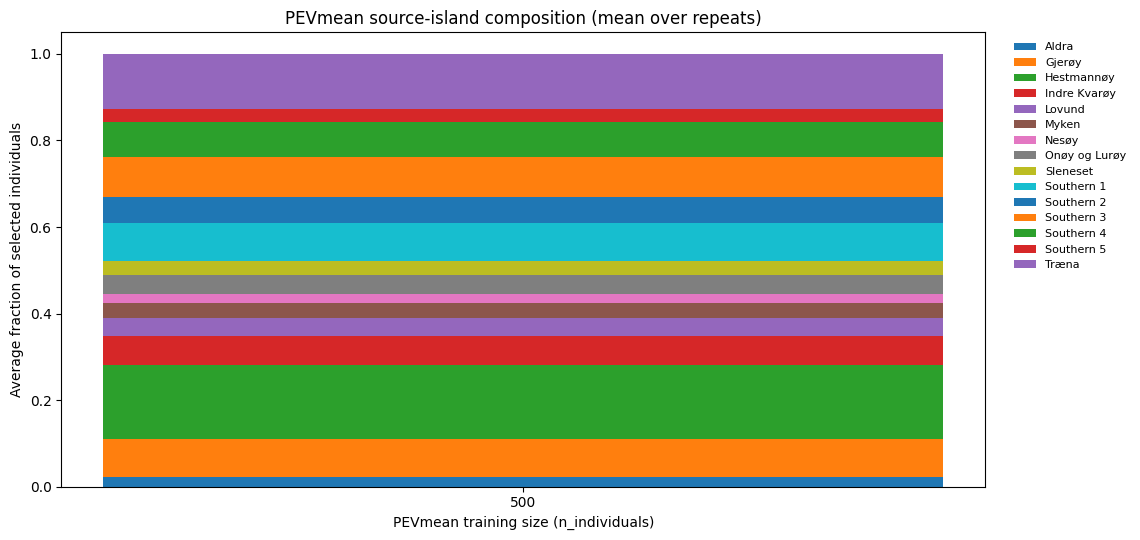

,n_individuals,source_name,mean_frac,mean_count,n_rows
0,500,Hestmannøy,0.1724,86.2,5
1,500,Træna,0.1272,63.6,5
2,500,Southern 3,0.0924,46.2,5
3,500,Southern 1,0.0880,44.0,5
4,500,Gjerøy,0.0860,43.0,5


In [31]:
# Visualize where PEVmean-selected individuals come from

# 1) Average composition per n_train (stacked bars)
comp_mean = (
    composition_df.groupby(['n_individuals', 'source_name'], as_index=False)
    .agg(
        mean_frac=('frac_selected_from_island', 'mean'),
        mean_count=('n_selected_from_island', 'mean'),
        n_rows=('repeat', 'size'),
    )
)

pivot_frac = comp_mean.pivot(index='n_individuals', columns='source_name', values='mean_frac').fillna(0.0)
pivot_frac = pivot_frac.sort_index()

plt.figure(figsize=(11.5, 5.5))
bottom = np.zeros(len(pivot_frac), dtype=float)
for col in pivot_frac.columns:
    vals = pivot_frac[col].to_numpy(dtype=float)
    if np.allclose(vals, 0.0):
        continue
    plt.bar(pivot_frac.index.astype(str), vals, bottom=bottom, label=col)
    bottom += vals

plt.ylabel('Average fraction of selected individuals')
plt.xlabel('PEVmean training size (n_individuals)')
plt.title('PEVmean source-island composition (mean over repeats)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# 2) Top-contributor islands table
top_contrib = (
    comp_mean.sort_values(['n_individuals', 'mean_frac'], ascending=[True, False])
    .groupby('n_individuals', as_index=False)
    .head(5)
    .reset_index(drop=True)
)

top_contrib